# Forecasting with foundation models

Foundation Models (FMs) have recently introduced a major paradigm shift in the field of time series forecasting. Driven by the same architectural breakthroughs that power Large Language Models (LLMs), these models offer powerful generalization capabilities out-of-the-box.

In the context of time series, a Foundation Model is a large-scale neural network (typically based on Transformer architectures) that has been pre-trained on massive and highly diverse datasets spanning multiple domains (e.g., finance, weather, web traffic, and retail).

Models such as **AWS Chronos**, **Google TimesFM2.5**, and **Salesforce MOIRAI** operate on a principle similar to language models: they treat time series values as a sequence of tokens. Because they have already "seen" millions of time series patterns during their pre-training phase, they can identify trends, seasonality, and complex dynamics in new, unseen data without requiring any domain-specific training.

## Foundation Models vs. Machine Learning Models

Foundation models and traditional machine learning models approach forecasting in fundamentally different ways. Understanding these distinctions is crucial for knowing when and how to deploy each method.

**Zero-Shot Prediction**

Machine learning models require a training phase. You must fit the model on your historical target data (and exogenous variables) so the algorithm can learn the optimal weights and parameters for your specific time series. Foundation models are capable of zero-shot prediction. Because the model's parameters are already frozen from its massive pre-training phase, it can generate forecasts on your data immediately, without explicitly "learning" from your specific dataset first.

**The Role of the fit Method**

Machine learning models must be trained: calling `.fit()` optimizes the model's internal parameters to minimize an error metric on your data. Foundation models, by contrast, arrive pre-trained, their weights are frozen and never updated. Calling `.fit()` is therefore not a training step; it simply stores the recent historical context (last window of observations, frequency, and scaling factors) so that `.predict()` has everything it needs at inference time.

**Context Window vs. Engineered Lags**

Machine learning models rely on explicitly engineered features. In **skforecast**, you define `lags` or `window_features` to create a tabular dataset where past values are used as columns to predict the target. Foundation models rely on a **context window**. You pass a raw, sequential chunk of recent historical data (e.g., the last 512 observations) directly into the model at inference time. The attention mechanism inside the model automatically decides which past data points are most relevant.

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">&#9998 Note</b>
</p>

For more details about forecasting with foundation models, visit <a href="https://otexts.com/fpppy/nbs/15-foundation-models.html">Forecasting: Principles and Practice, the Pythonic Way</a>.

</div>

## Foundation Models in skforecast

Skforecast's integration is built on two layers. First, `FoundationModel` acts as a unified wrapper that adapts each model's native API (Chronos-2, TimesFM 2.5, Moirai-2) behind a familiar scikit-learn interface (`.fit()`, `.predict()`, `.get_params()`). Second, `ForecasterFoundation` wraps that estimator to unlock the full skforecast ecosystem (backtesting, prediction intervals, multi-series support...) with the same code you would use for any other forecaster.

### Supported Foundation Models

|| `Chronos` | `TimesFM` | `Moirai` | `TabICL` |
|---|---|---|---|---|
| **Provider** | Amazon | Google | Salesforce | Soda-Inria |
| **GitHub** | [chronos-forecasting](https://github.com/amazon-science/chronos-forecasting) | [timesfm](https://github.com/google-research/timesfm) | [uni2ts](https://github.com/SalesforceAIResearch/uni2ts) | [tabicl](https://github.com/soda-inria/tabicl) |
| **Documentation** | [Chronos models](https://huggingface.co/collections/amazon/chronos-models-65f1791d630a8d57cb718444) | [TimesFM models](https://huggingface.co/collections/google/timesfm-release-66e4be5fdb56e960c1e482a6) | [Moirai-R models](https://huggingface.co/collections/Salesforce/moirai-r-models-65c8d3a94c51428c300e0742) | [TabICL Docs](https://tabicl.readthedocs.io/en/latest/) |
| **Available model IDs** | `amazon/chronos-2`<br>`autogluon/chronos-2-small`<br>`autogluon/chronos-2-synth` | `google/timesfm-2.5-200m-pytorch` | `Salesforce/moirai-2.0-R-small` | `soda-inria/tabicl` |
| **Backend** | PyTorch | PyTorch | PyTorch | PyTorch |
| **Forecasting type** | Zero-shot | Zero-shot | Zero-shot | Zero-shot |
| **Default `context_length`** | `8192` | `512` | `2048` | `4096` |
| **Max `context_length`** | `8192` | `16384` | `2048` | `4096` |
| **`max_horizon`** | No hard limit, set via `steps` at predict time | `512` | No hard limit, set via `steps` at predict time | No hard limit, set via `steps` at predict time |
| **Point forecast** | Median (0.5 quantile) | Mean (dedicated output array) | Median (0.5 quantile) | Mean (default, configurable to median) |
| **Covariate support (`exog`)** | Yes | No | No | Yes |
| **`cross_learning` parameter** | Yes (multi-series mode only) | No | No | No |
| **Install command** | `pip install chronos-forecasting` | `pip install git+https://github.com/google-research/timesfm.git` | `pip install uni2ts` | `pip install tabicl[forecast]` |

<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161 Tip</b>
</p>

All three models run on the CPU. However, a CUDA GPU is recommended for faster inference, especially with long context windows. The MPS backend is also detected automatically by <code>PyTorch</code> and can benefit Apple Silicon users.

</div>

### FoundationModel

Each foundation model (Chronos-2, TimesFM 2.5, Moirai-2) has its own API, input format, and inference logic. The `FoundationModel` class abstracts away these differences behind a single scikit-learn-compatible interface (`.fit()`, `.predict()`). Internally, it delegates to a model-specific adapter that handles all the implementation details.

### ForecasterFoundation

The `ForecasterFoundation` wraps a `FoundationModel` and exposes the same interface as any other skforecast forecaster. This means that you can use backtesting, prediction intervals, and multi-series support with the exact same code. It also makes it easy to compare a zero-shot Chronos model with a trained [`ForecasterRecursive`](../user_guides/autoregressive-forecaster.html) on the same dataset.

```text
                          ┌──────────────────────────┐
                          │   skforecast ecosystem   │
                          └─────────────┬────────────┘
                                        │
                          ┌─────────────┴────────────┐
                          │   ForecasterFoundation   │
                          │      (forecasting)       │
                          └─────────────┬────────────┘
                                        │
                          ┌─────────────┴────────────┐
                          │     FoundationModel      │
                          │   (skforecast Wrapper)   │
                          └────┬─────────────────┬───┘
                               │                 │
                      ┌────────┴────────┐ ┌──────┴──────────┐
                      │     .fit()      │ │    .predict()   │
                      │ (Store Context) │ │ (Zero-Shot Run) │
                      └────────┬────────┘ └──────┬──────────┘
                               │                 │
     ┌─────────────────────────┴─────────────────┴──────────────────────────┐
     │                       Internal Model Adapters                        │
     │  ┌─────────────┐   ┌────────────┐   ┌─────────────┐  ┌────────────┐  │
     │  │ AWS Chronos │   │   MOIRAI   │   │   TimesFM   │  │     ...    │  │
     │  └─────────────┘   └────────────┘   └─────────────┘  └────────────┘  │
     └──────────────────────────────────────────────────────────────────────┘
```

### Input Data Formats

`ForecasterFoundation` accepts several data formats for both the target series and exogenous variables.

**Target Series (`series`)**

The `series` parameter in the `.fit()` method supports both single-series and multi-series (global model) configurations.

| Mode | Allowed Data Type | Description |
| :--- | :--- | :--- |
| **Single-Series** | `pd.Series` | A single time series with a named index. |
| **Multi-Series (Wide)** | `pd.DataFrame` | Each column represents a separate time series. |
| **Multi-Series (Long)** | `pd.DataFrame` | MultiIndex (Level 0: series ID, Level 1: DatetimeIndex). |
| **Multi-Series (Dict)** | `dict[str, pd.Series]` | Keys are series identifiers, values are pandas Series. |

<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161 Tip</b>
</p>

While Long-format DataFrames are supported, they are converted to dictionaries internally. For best performance, pass a <code>dict[str, pd.Series]</code> directly.

</div>

**Exogenous Variables (`exog`)**

Exogenous variables must be aligned with the target series index. Currently, only **Chronos** supports covariates (see the <a href="#supported-foundation-models">Supported Foundation Models</a> table). TimesFM 2.5 and Moirai-2 do not accept exogenous variables.

| Mode | Allowed Data Type | Description |
| :--- | :--- | :--- |
| **Single-Series** | `pd.Series` or `pd.DataFrame` | Aligned to the target series index. |
| **Multi-Series (Dict)** | `dict[str, pd.Series \| pd.DataFrame \| None]` | One entry per series. |
| **Multi-Series (Broadcast)** | `pd.Series` or `pd.DataFrame` | Automatically applied to all series. |
| **Multi-Series (Long)** | `pd.DataFrame` | MultiIndex (Level 0: series ID, Level 1: DatetimeIndex). |

## Libraries and data

In [1]:
# Libraries
# ==============================================================================
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset
from skforecast.foundation import FoundationModel, ForecasterFoundation
from skforecast.model_selection import (
    TimeSeriesFold,
    backtesting_foundation
)
from skforecast.plot import set_dark_theme

color = '\033[1m\033[38;5;208m' 
print(f"{color}torch version: {torch.__version__}")
print(f"  Cuda available : {torch.cuda.is_available()}")
print(f"  MPS available  : {torch.backends.mps.is_available()}")

torch version: 2.4.1
  Cuda available : False
  MPS available  : True


In [2]:
# Data download
# ==============================================================================
data = fetch_dataset(name='vic_electricity')

# Aggregating in 1H intervals
# ==============================================================================
# The Date column is eliminated so that it does not generate an error when aggregating.
data = data.drop(columns="Date")
data = (
    data
    .resample(rule="h", closed="left", label="right")
    .agg({
        "Demand": "mean",
        "Temperature": "mean",
        "Holiday": "mean",
    })
)
data.head(3)

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

,Demand,Temperature,Holiday
Time,,,
2011-12-31 14:00:00,4323.095350,21.225,1.0
2011-12-31 15:00:00,3963.264688,20.625,1.0
2011-12-31 16:00:00,3950.913495,20.325,1.0


In [3]:
# Split data into train-test
# ==============================================================================
data = data.loc['2012-01-01 00:00:00':'2014-12-30 23:00:00', :].copy()
end_train = '2014-11-30 23:59:00'
data_train = data.loc[: end_train, :].copy()
data_test  = data.loc[end_train:, :].copy()

print(f"Train dates: {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Test dates : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")


Train dates: 2012-01-01 00:00:00 --- 2014-11-30 23:00:00  (n=25560)
Test dates : 2014-12-01 00:00:00 --- 2014-12-30 23:00:00  (n=720)


<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff1744;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning: Data Leakage</b>
</p>

The following examples use a widely available public dataset for illustrative purposes. It is highly probable that the foundation models (Chronos, TimesFM, Moirai) were exposed to these data points during their pre-training phase. As a result, the predictions may be more optimistic than what would be achieved in a real-world production environment with private or novel data.

</div>

## Chronos

A <code>[ForecasterFoundation](../api/forecasterfoundation.html)</code> is created using Amazon's **Chronos-2-small** model.

In [4]:
# Create ForecasterFoundation
# ==============================================================================
estimator = FoundationModel(model_id="autogluon/chronos-2-small")
forecaster = ForecasterFoundation(estimator=estimator)

Each adapter accepts **additional keyword arguments** that control model-specific behavior (e.g., `context_length`, `device_map`, `torch_dtype`). These can be passed directly through the `FoundationModel` constructor. 

For the full list of available parameters, see the API reference: [`ChronosAdapter`](../api/FoundationModel.html#skforecast.foundation._adapters.ChronosAdapter), [`TimesFMAdapter`](../api/FoundationModel.html#skforecast.foundation._adapters.TimesFMAdapter), [`MoiraiAdapter`](../api/FoundationModel.html#skforecast.foundation._adapters.MoiraiAdapter).

<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161 Tip</b>
</p>

<p>
While <code>.fit()</code> is used here to store the historical context and metadata, it is not strictly required. Foundation models can generate forecasts by passing the context directly to <code>.predict()</code> via the <code>context</code> parameter. However, calling <code>.fit()</code> first simplifies subsequent calls to <code>.predict()</code>, <code>.predict_interval()</code>, and <code>.predict_quantiles()</code>.
</p>

</div>

In [5]:
# Train ForecasterFoundation
# ==============================================================================
forecaster.fit(
    series = data_train["Demand"], 
    exog   = data_train[["Temperature", "Holiday"]]
)
forecaster

==================== 
ForecasterFoundation 
==================== 
Model: autogluon/chronos-2-small 
Context length: 8192 
Series names: Demand 
Exogenous included: True 
Exogenous names: Temperature, Holiday 
Context range: {'Demand': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-11-30 23:00:00')]} 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Creation date: 2026-04-23 13:03:01 
Last fit date: 2026-04-23 13:03:01 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

Three methods can be used to predict the next $n$ steps ahead: `predict()`, `predict_interval()`, and `predict_quantiles()`. All these methods allow for passing `context` and `context_exog` to override the historical context used by the underlying model to generate predictions.

In [6]:
# Predictions: point forecast
# ==============================================================================
steps = 24
predictions = forecaster.predict(
                  steps = steps,
                  exog  = data_test[["Temperature", "Holiday"]]
              )

predictions.head(3)

,level,pred
2014-12-01 00:00:00,Demand,5488.940430
2014-12-01 01:00:00,Demand,5431.977539
2014-12-01 02:00:00,Demand,5347.607422


In [7]:
# Predictions: intervals
# ==============================================================================
predictions_intervals = forecaster.predict_interval(
                            steps    = steps,
                            exog     = data_test[["Temperature", "Holiday"]],
                            interval = [10, 90],  # 80% prediction interval
                        )

predictions_intervals.head(3)

,level,pred,lower_bound,upper_bound
2014-12-01 00:00:00,Demand,5488.940430,5333.779785,5682.048340
2014-12-01 01:00:00,Demand,5431.977539,5262.784180,5657.536133
2014-12-01 02:00:00,Demand,5347.607422,5161.753418,5592.012695


In [8]:
# Backtesting
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = len(data.loc[:end_train]),
         refit              = False
     )

metrics_chronos, backtest_predictions = backtesting_foundation(
    forecaster        = forecaster,
    series            = data['Demand'],
    exog              = data[["Temperature", "Holiday"]],
    cv                = cv,
    metric            = 'mean_absolute_error',
    suppress_warnings = True
)

print("Backtest metrics")
display(metrics_chronos)
print("")
print("Backtest predictions")
backtest_predictions.head(4)

  0%|          | 0/30 [00:00<?, ?it/s]

Backtest metrics


,mean_absolute_error
0,158.693401



Backtest predictions


,level,fold,pred
2014-12-01 00:00:00,Demand,0,5488.940430
2014-12-01 01:00:00,Demand,0,5431.977539
2014-12-01 02:00:00,Demand,0,5347.607422
2014-12-01 03:00:00,Demand,0,5256.606934


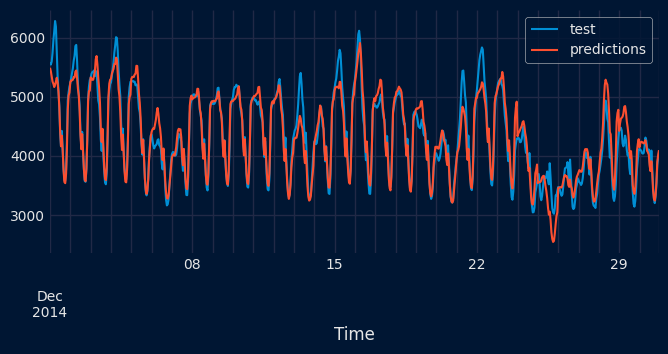

In [9]:
# Plot predictions
# ==============================================================================
set_dark_theme()
fig, ax = plt.subplots(figsize=(7, 3))
data_test['Demand'].plot(ax=ax, label='test')
backtest_predictions['pred'].plot(ax=ax, label='predictions')
ax.legend();

### Multiple series (global model)

The class <code>[ForecasterFoundation](../api/forecasterfoundation.html)</code> allows modeling and forecasting multiple series with a single model.

In [10]:
# Data
# ==============================================================================
data_multiseries = fetch_dataset(name="items_sales")
display(data_multiseries.head(3))

╭─────────────────────── items_sales ───────────────────────╮
│ Description:                                              │
│ Simulated time series for the sales of 3 different items. │
│                                                           │
│ Source:                                                   │
│ Simulated data.                                           │
│                                                           │
│ URL:                                                      │
│ https://raw.githubusercontent.com/skforecast/skforecast-  │
│ datasets/main/data/simulated_items_sales.csv              │
│                                                           │
│ Shape: 1097 rows x 3 columns                              │
╰───────────────────────────────────────────────────────────╯

,item_1,item_2,item_3
date,,,
2012-01-01,8.253175,21.047727,19.429739
2012-01-02,22.777826,26.578125,28.009863
2012-01-03,27.549099,31.751042,32.078922


In [11]:
# Split data into train-test
# ==============================================================================
end_train = '2014-07-15 23:59:00'
data_multiseries_train = data_multiseries.loc[:end_train, :]
data_multiseries_test  = data_multiseries.loc[end_train:, :]

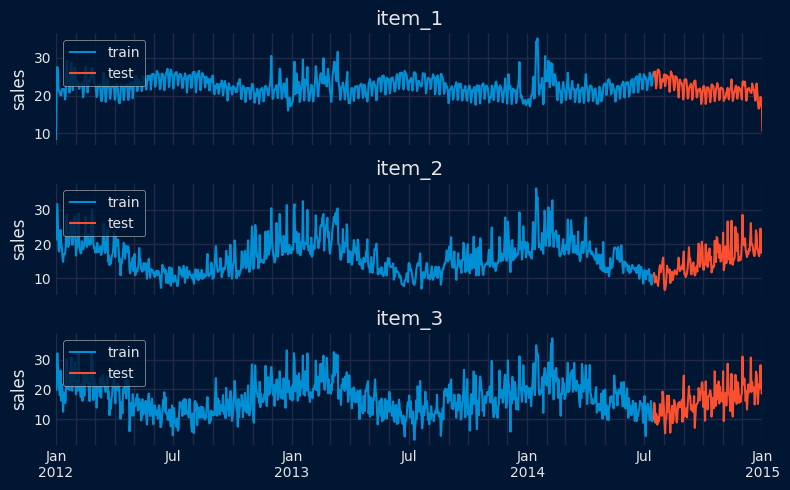

In [12]:
# Plot time series
# ==============================================================================
set_dark_theme()
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 5), sharex=True)

for i, col in enumerate(data_multiseries.columns):
    data_multiseries_train[col].plot(ax=axes[i], label='train')
    data_multiseries_test[col].plot(ax=axes[i], label='test')
    axes[i].set_title(col)
    axes[i].set_ylabel('sales')
    axes[i].set_xlabel('')
    axes[i].legend(loc='upper left')

fig.tight_layout()
plt.show();

In this example, instead of calling `fit()`, the context is passed directly to the `predict()` method.

In [13]:
# Create and train ForecasterFoundation
# ==============================================================================
estimator = FoundationModel(model_id = "autogluon/chronos-2-small")
forecaster = ForecasterFoundation(estimator = estimator)

# fit() is optional; context is passed directly to predict()
# forecaster.fit(series=data_multiseries_train)

forecaster

==================== 
ForecasterFoundation 
==================== 
Model: autogluon/chronos-2-small 
Context length: 8192 
Series names: None 
Exogenous included: False 
Exogenous names: None 
Context range: None 
Training index type: None 
Training index frequency: None 
Creation date: 2026-04-23 13:03:07 
Last fit date: None 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

In [14]:
# Predictions for all series (levels)
# ==============================================================================
steps = 24

predictions_items = forecaster.predict(
                        steps   = len(data_multiseries_test), 
                        levels  = None,  # All levels are predicted
                        context = data_multiseries_train
                    )

predictions_items.head()

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_py12/lib/python3.12/site-packa │
│ ges/skforecast/utils/utils.py:2802                                                   │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

,level,pred
2014-07-16,item_1,25.478813
2014-07-16,item_2,10.479328
2014-07-16,item_3,11.807503
2014-07-17,item_1,25.194397
2014-07-17,item_2,10.714880


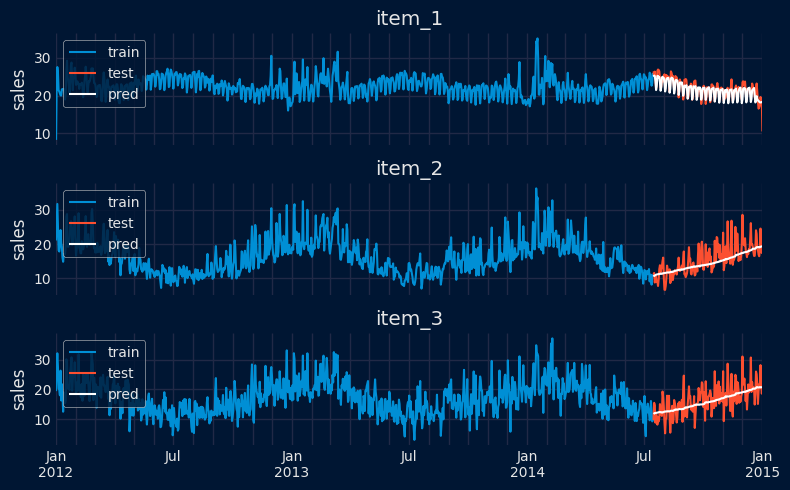

In [15]:
# Plot predictions
# ==============================================================================
set_dark_theme()
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 5), sharex=True)

for i, col in enumerate(data_multiseries.columns):
    
    data_multiseries_train[col].plot(ax=axes[i], label='train')
    data_multiseries_test[col].plot(ax=axes[i], label='test')
    predictions_items.query(f"level == '{col}'").plot(
        ax=axes[i], label='predictions', color='white'
    )

    axes[i].set_title(col)
    axes[i].set_ylabel('sales')
    axes[i].set_xlabel('')
    axes[i].legend(loc='upper left')

fig.tight_layout()
plt.show();

In [16]:
# Interval predictions for item_1 and item_2
# ==============================================================================
predictions_intervals = forecaster.predict_interval(
                            steps    = 24,
                            levels   = ['item_1', 'item_2'],
                            context  = data_multiseries_train,
                            interval = [10, 90],  # 80% prediction interval
                        )

predictions_intervals.head()

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_py12/lib/python3.12/site-packa │
│ ges/skforecast/utils/utils.py:2802                                                   │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

,level,pred,lower_bound,upper_bound
2014-07-16,item_1,25.393276,24.595732,26.200489
2014-07-16,item_2,10.694120,8.742786,13.271328
2014-07-17,item_1,25.141916,24.192814,26.036993
2014-07-17,item_2,10.868244,8.804617,13.735439
2014-07-18,item_1,25.119213,24.065229,26.078648


## Other foundation models

The examples above use the Amazon Chronos model, but the same code structure applies to any other foundation model supported by skforecast. To use a different model, simply change the `model_id` parameter when instantiating the <code>[FoundationModel](../api/foundationmodel.html)</code> wrapper. The rest of the forecasting pipeline remains unchanged, allowing you to easily compare different foundation models on your dataset.

### TimesFM2.5

A <code>[ForecasterFoundation](../api/forecasterfoundation.html)</code> is created using Google's **TimesFM-2.5-200m** model.

In [17]:
# Create ForecasterFoundation
# ==============================================================================
estimator = FoundationModel(model_id="google/timesfm-2.5-200m-pytorch")
forecaster = ForecasterFoundation(estimator = estimator)

In [18]:
# Train ForecasterFoundation
# ==============================================================================
forecaster.fit(series=data_train["Demand"])
forecaster

==================== 
ForecasterFoundation 
==================== 
Model: google/timesfm-2.5-200m-pytorch 
Context length: 512 
Series names: Demand 
Exogenous included: False 
Exogenous names: None 
Context range: {'Demand': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-11-30 23:00:00')]} 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Creation date: 2026-04-23 13:03:08 
Last fit date: 2026-04-23 13:03:08 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

In [19]:
# Predictions: point forecast
# ==============================================================================
steps = 24
predictions = forecaster.predict(steps=steps)
predictions.head(3)

,level,pred
2014-12-01 00:00:00,Demand,5665.909668
2014-12-01 01:00:00,Demand,5668.937012
2014-12-01 02:00:00,Demand,5760.318848


In [20]:
# Predictions: intervals
# ==============================================================================
predictions_intervals = forecaster.predict_interval(
    steps    = steps,
    interval = [10, 90],  # 80% prediction interval
)
predictions_intervals.head(3)

,level,pred,lower_bound,upper_bound
2014-12-01 00:00:00,Demand,5665.909668,5549.081055,5800.553223
2014-12-01 01:00:00,Demand,5668.937012,5457.991699,5904.702148
2014-12-01 02:00:00,Demand,5760.318848,5443.220703,6093.883789


In [21]:
# Backtesting
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = len(data.loc[:end_train]),
         refit              = False
     )

metrics_timesfm, backtest_predictions = backtesting_foundation(
    forecaster        = forecaster,
    series            = data['Demand'],
    cv                = cv,
    metric            = 'mean_absolute_error',
    suppress_warnings = True
)

print("Backtest metrics")
display(metrics_timesfm)
print("")
print("Backtest predictions")
backtest_predictions.head(4)

  0%|          | 0/168 [00:00<?, ?it/s]

Backtest metrics


,mean_absolute_error
0,163.088465



Backtest predictions


,level,fold,pred
2014-07-16 00:00:00,Demand,0,6188.992676
2014-07-16 01:00:00,Demand,0,5991.776855
2014-07-16 02:00:00,Demand,0,5831.969727
2014-07-16 03:00:00,Demand,0,5704.315430


### Moirai

A <code>[ForecasterFoundation](../api/forecasterfoundation.html)</code> is created using Salesforce's **Moirai-2.0-R-small** model.

In [22]:
# Create ForecasterFoundation
# ==============================================================================
estimator = FoundationModel(model_id="Salesforce/moirai-2.0-R-small")
forecaster = ForecasterFoundation(estimator=estimator)

In [23]:
# Train ForecasterFoundation
# ==============================================================================
forecaster.fit(series=data_train["Demand"])
forecaster

==================== 
ForecasterFoundation 
==================== 
Model: Salesforce/moirai-2.0-R-small 
Context length: 2048 
Series names: Demand 
Exogenous included: False 
Exogenous names: None 
Context range: {'Demand': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-11-30 23:00:00')]} 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Creation date: 2026-04-23 13:03:22 
Last fit date: 2026-04-23 13:03:22 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

In [24]:
# Predictions: point forecast
# ==============================================================================
steps = 24
predictions = forecaster.predict(steps=steps)
predictions.head(3)

/var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_11574/2957951684.py:4: UserWarning: MPS device is not supported by Moirai because the uni2ts library uses float64 operations internally. Falling back to CPU.
  predictions = forecaster.predict(steps=steps)


,level,pred
2014-12-01 00:00:00,Demand,5795.251953
2014-12-01 01:00:00,Demand,5986.599121
2014-12-01 02:00:00,Demand,6149.235352


In [25]:
# Predictions: intervals
# ==============================================================================
predictions_intervals = forecaster.predict_interval(
    steps    = steps,
    interval = [10, 90],  # 80% prediction interval
)
predictions_intervals.head(3)

,level,pred,lower_bound,upper_bound
2014-12-01 00:00:00,Demand,5795.251953,5628.000488,5953.445312
2014-12-01 01:00:00,Demand,5986.599121,5673.974121,6254.291016
2014-12-01 02:00:00,Demand,6149.235352,5728.174805,6538.167969


In [26]:
# Backtesting
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = len(data.loc[:end_train]),
         refit              = False
     )

metrics_moirai, backtest_predictions = backtesting_foundation(
    forecaster        = forecaster,
    series            = data['Demand'],
    cv                = cv,
    metric            = 'mean_absolute_error',
    suppress_warnings = True
)

print("Backtest metrics")
display(metrics_moirai)
print("")
print("Backtest predictions")
backtest_predictions.head(4)

  0%|          | 0/168 [00:00<?, ?it/s]

Backtest metrics


,mean_absolute_error
0,154.080703



Backtest predictions


,level,fold,pred
2014-07-16 00:00:00,Demand,0,6224.538086
2014-07-16 01:00:00,Demand,0,6114.214355
2014-07-16 02:00:00,Demand,0,5991.563965
2014-07-16 03:00:00,Demand,0,5959.375488


### TabICL

A <code>[ForecasterFoundation](../api/forecasterfoundation.html)</code> is created using Soda-Inria's **TabICL** model.

In this case, the `context_length` is reduced from the default of 4096 to 72 to speed up inference. For the best performance, use as much context as possible, depending on computational capacity.

In [54]:
# Create ForecasterFoundation
# ==============================================================================
estimator = FoundationModel(model_id="soda-inria/tabicl", context_length=72)
forecaster = ForecasterFoundation(estimator=estimator)

In [55]:
# Train ForecasterFoundation
# ==============================================================================
forecaster.fit(
    series = data_train["Demand"], 
    exog   = data_train[["Temperature", "Holiday"]]
)
forecaster

==================== 
ForecasterFoundation 
==================== 
Model: soda-inria/tabicl 
Context length: 72 
Series names: Demand 
Exogenous included: True 
Exogenous names: Temperature, Holiday 
Context range: {'Demand': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-11-30 23:00:00')]} 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Creation date: 2026-04-23 13:12:17 
Last fit date: 2026-04-23 13:12:17 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

In [56]:
# Predictions: point forecast
# ==============================================================================
steps = 24
predictions = forecaster.predict(
                  steps = steps,
                  exog  = data_test[["Temperature", "Holiday"]]
              )

predictions.head(3)

Predicting time series:   0%|          | 0/1 [00:00<?, ?it/s]

Predicting time series: 100%|██████████| 1/1 [00:00<00:00,  1.78it/s]


,level,pred
2014-12-01 00:00:00,Demand,5672.044434
2014-12-01 01:00:00,Demand,5729.507812
2014-12-01 02:00:00,Demand,5774.244141


In [57]:
# Predictions: intervals
# ==============================================================================
predictions_intervals = forecaster.predict_interval(
                            steps    = steps,
                            exog     = data_test[["Temperature", "Holiday"]],
                            interval = [10, 90],  # 80% prediction interval
                        )

predictions_intervals.head(3)

Predicting time series:   0%|          | 0/1 [00:00<?, ?it/s]

Predicting time series: 100%|██████████| 1/1 [00:00<00:00,  2.13it/s]


,level,pred,lower_bound,upper_bound
2014-12-01 00:00:00,Demand,5684.679199,5378.824707,5957.539551
2014-12-01 01:00:00,Demand,5745.276367,5359.950195,6097.789062
2014-12-01 02:00:00,Demand,5808.789551,5236.602539,6276.870117


In [58]:
# Backtesting
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = len(data.loc[:end_train]),
         refit              = False
     )

metrics_tabicl, backtest_predictions = backtesting_foundation(
    forecaster        = forecaster,
    series            = data['Demand'],
    exog              = data[["Temperature", "Holiday"]],
    cv                = cv,
    metric            = 'mean_absolute_error',
    suppress_warnings = True
)

print("Backtest metrics")
display(metrics_tabicl)
print("")
print("Backtest predictions")
backtest_predictions.head(4)

  0%|          | 0/168 [00:00<?, ?it/s]



Predicting time series: 100%|██████████| 1/1 [00:00<00:00,  1.54it/s]


Predicting time series: 100%|██████████| 1/1 [00:00<00:00,  1.74it/s]


Predicting time series: 100%|██████████| 1/1 [00:00<00:00,  1.67it/s]


Predicting time series: 100%|██████████| 1/1 [00:00<00:00,  2.12it/s]


Predicting time series: 100%|██████████| 1/1 [00:00<00:00,  2.09it/s]


Predicting time series: 100%|██████████| 1/1 [00:00<00:00,  2.22it/s]


Predicting time series: 100%|██████████| 1/1 [00:00<00:00,  1.47it/s]


Predicting time series: 100%|██████████| 1/1 [00:00<00:00,  1.54it/s]


Predicting time series: 100%|██████████| 1/1 [00:00<00:00,  1.69it/s]


Predicting time series: 100%|██████████| 1/1 [00:00<00:00,  2.19it/s]


Predicting time series: 100%|██████████| 1/1 [00:00<00:00,  2.28it/s]


Predicting time series: 100%|██████████| 1/1 [00:00<00:00,  2.27it/s]


Predicting time series: 100%|██████████| 1/1 [00:00<00:00,  2.10it/s]


Predicting time series: 100%|██████████| 1/1 [00:00<00:00,  2.

Backtest metrics


,mean_absolute_error
0,291.010684



Backtest predictions


,level,fold,pred
2014-07-16 00:00:00,Demand,0,6206.784668
2014-07-16 01:00:00,Demand,0,6153.166016
2014-07-16 02:00:00,Demand,0,6103.279785
2014-07-16 03:00:00,Demand,0,6089.614746


## Model comparison

The following table summarizes the backtesting results (Mean Absolute Error) for the three foundation models on the same dataset.

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">&#9998 Note</b>
</p>

Chronos-2 is the only model that supports exogenous variables, so its backtesting includes them. TimesFM and Moirai do not use exogenous variables. This difference should be considered when comparing results.

</div>

In [ ]:
# Comparison of backtesting metrics
# ==============================================================================
comparison = pd.DataFrame({
    "Model": [
        "Chronos-2 (small)*",
        "TimesFM-2.5 (200m)",
        "Moirai-2.0-R (small)",
        "TabICLv2"
    ],
    "mean_absolute_error": [
        metrics_chronos["mean_absolute_error"].iloc[0],
        metrics_timesfm["mean_absolute_error"].iloc[0],
        metrics_moirai["mean_absolute_error"].iloc[0],
        metrics_tabicl["mean_absolute_error"].iloc[0]  # Reduced context length
    ],
})

comparison.style.highlight_min(
    subset="mean_absolute_error", color="green"
).format(precision=4)

,Model,mean_absolute_error
0,Chronos-2 (small)*,158.6934
1,TimesFM-2.5 (200m),163.0885
2,Moirai-2.0-R (small),154.0807
3,TabICLv2,291.0107
